Stability katsayısı (mu): 0.0030


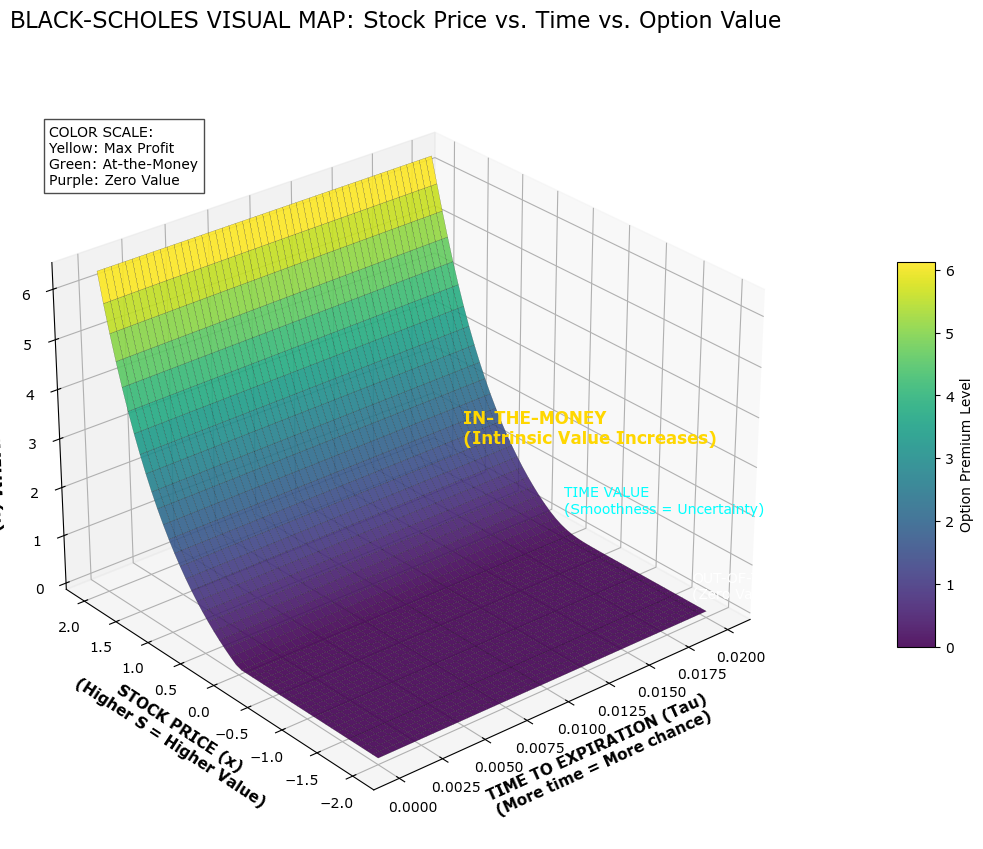

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Part 1: PARAMETERS
sigma = 0.2    # Volatility
r = 0.05       # Risk-free rate
K = 100        # Strike Price
T = 1.0        # Time to maturıty

# Part 2: GRID
Nx = 50
Nt = 1000
x_min, x_max = -2.0, 2.0
tau_max = T * (sigma**2 / 2)

x = np.linspace(x_min, x_max, Nx)
tau = np.linspace(0, tau_max, Nt)
dx = x[1] - x[0]
dtau = tau[1] - tau[0]

# Stability (CFL) Check: mu <= 0.5
mu = dtau / (dx**2)
print(f"Stability katsayısı (mu): {mu:.4f}")

# Part 3: SOLVING
u = np.zeros((Nx, Nt))

# (Payoff): V(S,T) = max(S-K, 0)
for i in range(Nx):
    u[i, 0] = max(np.exp(x[i]) - 1, 0)

# Explicit Finite Difference
for j in range(0, Nt - 1):
    for i in range(1, Nx - 1):
        u[i, j+1] = u[i, j] + mu * (u[i+1, j] - 2*u[i, j] + u[i-1, j])
    
    # Boundary Conditions
    u[0, j+1] = 0 
    u[-1, j+1] = np.exp(x[-1]) - np.exp(-r * tau[j+1])

# Part 4: VISUALIZING
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

X, T_mesh = np.meshgrid(tau, x)
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T_mesh, u, cmap='viridis', edgecolor='k', lw=0.1, alpha=0.9)

ax.set_xlabel('\nTIME TO EXPIRATION (Tau)\n(More time = More chance)', fontsize=11, fontweight='bold')
ax.set_ylabel('\nSTOCK PRICE (x)\n(Higher S = Higher Value)', fontsize=11, fontweight='bold')
ax.set_zlabel('\nOPTION PREMIUM (u)', fontsize=12, fontweight='bold')

#In the Money
ax.text(0.02, 1.5, 0.7, "IN-THE-MONEY\n(Intrinsic Value Increases)", color='gold', fontsize=12, fontweight='bold')
#Out of the money
ax.text(0.02, -1.8, 0.1, "OUT-OF-THE-MONEY\n(Zero Value)", color='white', fontsize=10)

ax.text(tau_max, 0, 0.4, "TIME VALUE\n(Smoothness = Uncertainty)", color='cyan', fontsize=10)

ax.text2D(0.05, 0.85, "COLOR SCALE:\nYellow: Max Profit\nGreen: At-the-Money\nPurple: Zero Value", 
          transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7))

ax.view_init(elev=28, azim=-130)
ax.dist = 10 

cbar = fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Option Premium Level')

plt.title('BLACK-SCHOLES VISUAL MAP: Stock Price vs. Time vs. Option Value', fontsize=16, pad=30)
plt.show()